# Customer Segmentation using K-Means Clustering

## Problem Statement and Objective

The objective of this task is to segment mall customers into different groups based on their annual income and spending score.

Customer segmentation helps businesses understand different types of customers and create better marketing strategies for each group.

In this task, K-Means Clustering is used to divide customers into meaningful segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Dataset Description and Loading

The dataset used in this task is the Mall Customers Dataset.

It contains customer information such as:

- Customer ID
- Gender
- Age
- Annual Income
- Spending Score

The main purpose of this dataset is to group customers based on their income and spending behavior.

In [2]:
# Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
data.head()
# Dataset shape
print("Dataset shape:", data.shape)
# Dataset information
data.info()
# Statistical summary
data.describe()

Dataset shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Data Cleaning and Preprocessing

In this section, we clean the dataset by:

- Removing extra spaces from column names
- Renaming long column names for easy use
- Checking missing values
- Removing duplicate records

In [4]:
# Remove extra spaces from column names
data.columns = data.columns.str.strip()

# Rename columns for easier use
data.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
}, inplace=True)

# Display updated column names
data.columns
# Check missing values
data.isnull().sum()
# Remove duplicate rows if any
data = data.drop_duplicates()

# Check dataset shape after removing duplicates
data.shape

(200, 5)

## Exploratory Data Analysis

EDA helps us understand the structure and patterns in the dataset.

We will analyze:

- Gender distribution
- Age distribution
- Annual income distribution
- Spending score distribution
- Relationship between annual income and spending score

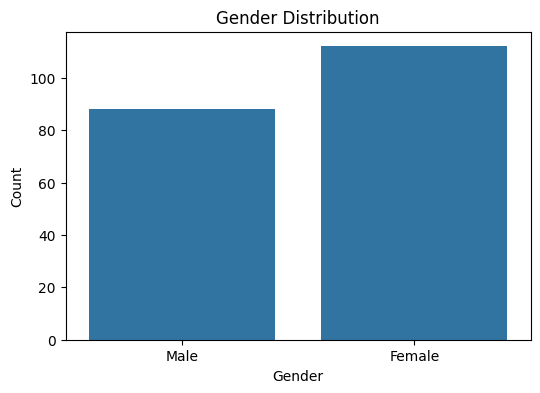

In [21]:
# Gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", data=data)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

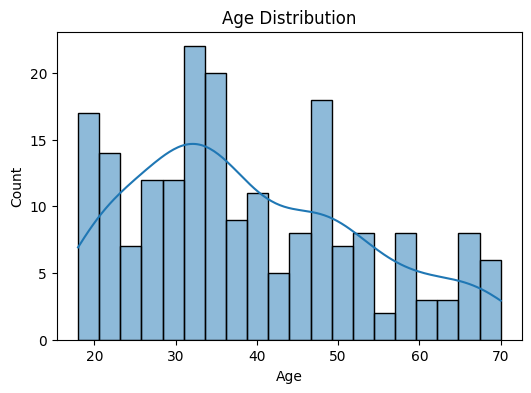

In [20]:
# Age distribution
plt.figure(figsize=(6, 4))
sns.histplot(data["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

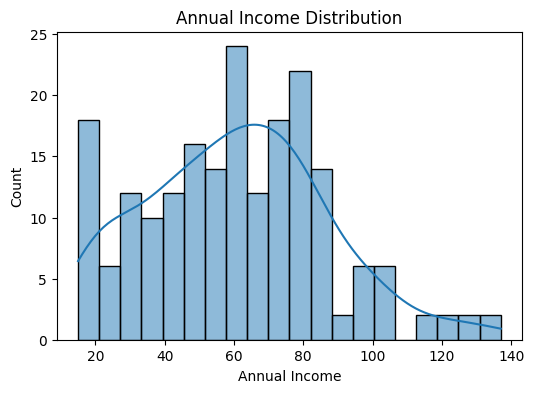

In [19]:
# Annual Income distribution
plt.figure(figsize=(6, 4))
sns.histplot(data["Annual_Income"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

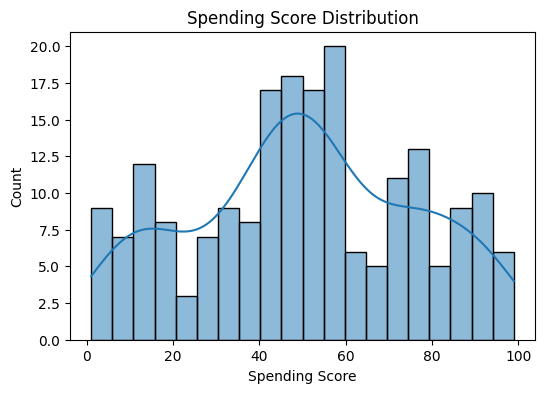

In [18]:
# Spending Score distribution
plt.figure(figsize=(6, 4))
sns.histplot(data["Spending_Score"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()

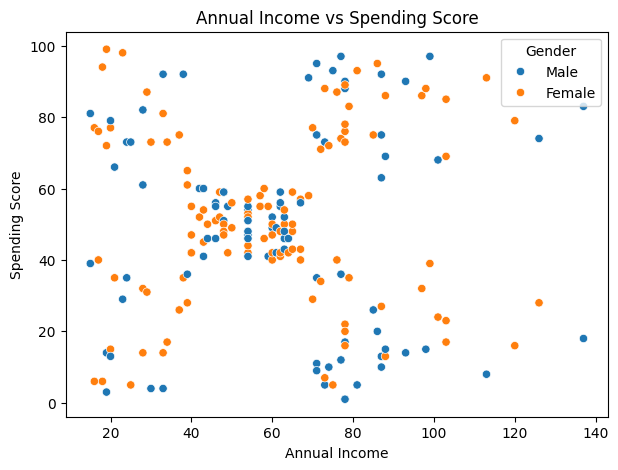

In [17]:
# Annual Income vs Spending Score
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Gender",
    data=data
)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

## Feature Selection

For customer segmentation, we use:

- Annual Income
- Spending Score

These two features are useful because they show how much a customer earns and how much they spend.

In [6]:
# Select features for clustering
X = data[["Annual_Income", "Spending_Score"]]

# Display selected features
X.head()

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Feature Scaling

K-Means Clustering is distance-based, so scaling is important.

StandardScaler is used to convert the data into a standard scale.

In [7]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display first 5 scaled values
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## Elbow Method

The elbow method is used to find the best number of clusters.

WCSS stands for Within-Cluster Sum of Squares.

A lower WCSS means customers inside each cluster are closer to each other.

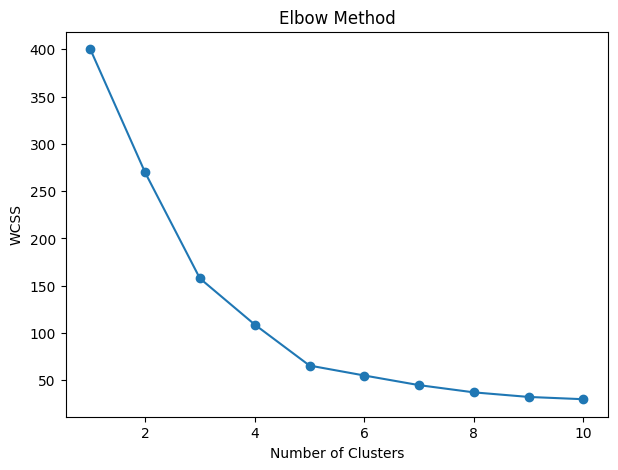

In [8]:
# Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Silhouette Score

Silhouette Score is used to evaluate clustering quality.

The score ranges from -1 to 1.

- A score close to 1 means clusters are well separated.
- A score close to 0 means clusters are overlapping.
- A negative score means clustering is poor.

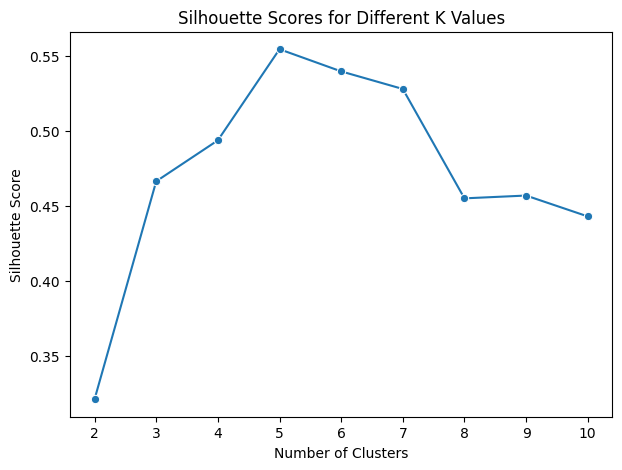

In [10]:
# Calculate silhouette scores for different values of K
silhouette_results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    silhouette_results.append({
        "Number of Clusters": k,
        "Silhouette Score": score
    })

silhouette_df = pd.DataFrame(silhouette_results)
silhouette_df
# Visualize silhouette scores
plt.figure(figsize=(7, 5))
sns.lineplot(
    x="Number of Clusters",
    y="Silhouette Score",
    data=silhouette_df,
    marker="o"
)
plt.title("Silhouette Scores for Different K Values")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

## K-Means Model Building

Based on the elbow method and common structure of the Mall Customers Dataset, we select 5 clusters.

The K-Means model assigns each customer to one of the 5 customer segments.

In [11]:
# Apply K-Means clustering
final_k = 5

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
data["Cluster"] = kmeans.fit_predict(X_scaled)

# Display cluster counts
data["Cluster"].value_counts()
# Display dataset with cluster column
data.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Cluster Visualization

This scatter plot shows customer segments based on annual income and spending score.

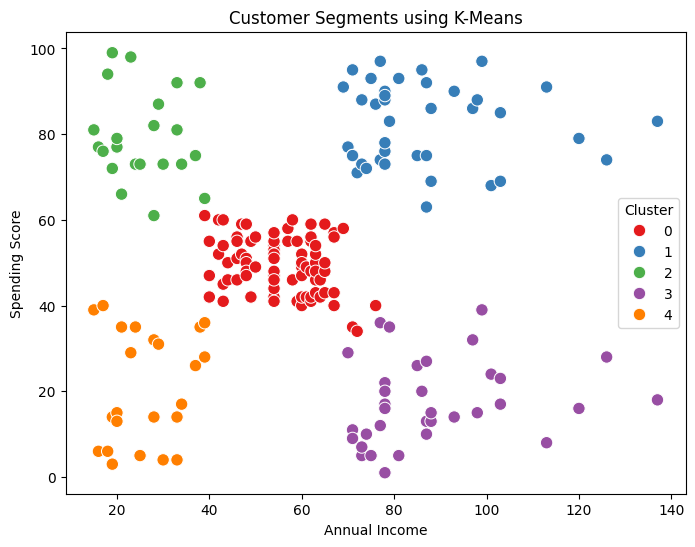

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="Set1",
    data=data,
    s=80
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.show()

## PCA Visualization

PCA is used to reduce data dimensions and visualize clusters more clearly.

Although we are using only two features, PCA is included for learning and visualization purposes.

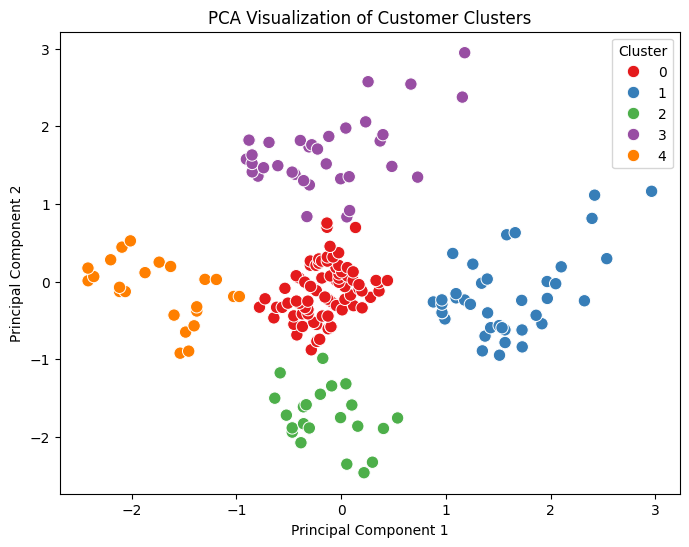

In [13]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

data["PCA1"] = X_pca[:, 0]
data["PCA2"] = X_pca[:, 1]

# PCA visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    data=data,
    s=80
)

plt.title("PCA Visualization of Customer Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

## Cluster Analysis

In this section, we analyze each cluster using average age, annual income, and spending score.

This helps us understand the behavior of each customer segment.

In [14]:
# Cluster summary
cluster_summary = data.groupby("Cluster")[["Age", "Annual_Income", "Spending_Score"]].mean()

cluster_summary

,Age,Annual_Income,Spending_Score
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


## Marketing Strategy Suggestions

Based on the average income and spending score of each cluster, suitable marketing strategies are suggested.

In [15]:
print("Marketing Strategies for Each Cluster:")

for cluster in sorted(data["Cluster"].unique()):
    income = cluster_summary.loc[cluster, "Annual_Income"]
    spending = cluster_summary.loc[cluster, "Spending_Score"]
    age = cluster_summary.loc[cluster, "Age"]

    print(f"\nCluster {cluster}:")
    print(f"Average Age: {age:.1f}")
    print(f"Average Income: {income:.1f}")
    print(f"Average Spending Score: {spending:.1f}")

    if income >= 60 and spending >= 60:
        print("Segment Type: High Income, High Spending")
        print("Strategy: Offer premium products, VIP membership, luxury deals, and exclusive discounts.")

    elif income >= 60 and spending < 40:
        print("Segment Type: High Income, Low Spending")
        print("Strategy: Use personalized offers, loyalty rewards, and high-value product recommendations.")

    elif income < 40 and spending >= 60:
        print("Segment Type: Low Income, High Spending")
        print("Strategy: Offer budget-friendly bundles, student deals, seasonal discounts, and installment options.")

    elif income < 40 and spending < 40:
        print("Segment Type: Low Income, Low Spending")
        print("Strategy: Use basic discount campaigns, awareness ads, and low-price product promotions.")

    else:
        print("Segment Type: Average Income, Average Spending")
        print("Strategy: Use regular promotions, loyalty points, and personalized email campaigns.")

Marketing Strategies for Each Cluster:

Cluster 0:
Average Age: 42.7
Average Income: 55.3
Average Spending Score: 49.5
Segment Type: Average Income, Average Spending
Strategy: Use regular promotions, loyalty points, and personalized email campaigns.

Cluster 1:
Average Age: 32.7
Average Income: 86.5
Average Spending Score: 82.1
Segment Type: High Income, High Spending
Strategy: Offer premium products, VIP membership, luxury deals, and exclusive discounts.

Cluster 2:
Average Age: 25.3
Average Income: 25.7
Average Spending Score: 79.4
Segment Type: Low Income, High Spending
Strategy: Offer budget-friendly bundles, student deals, seasonal discounts, and installment options.

Cluster 3:
Average Age: 41.1
Average Income: 88.2
Average Spending Score: 17.1
Segment Type: High Income, Low Spending
Strategy: Use personalized offers, loyalty rewards, and high-value product recommendations.

Cluster 4:
Average Age: 45.2
Average Income: 26.3
Average Spending Score: 20.9
Segment Type: Low Income, L

## Save Final Dataset

The final dataset with cluster labels is saved as a CSV file.

In [16]:
# Save final clustered dataset
data.to_csv("Mall_Customers_Clustered.csv", index=False)

print("Final clustered dataset saved as Mall_Customers_Clustered.csv")

Final clustered dataset saved as Mall_Customers_Clustered.csv


## Final Conclusion

In this task, customer segmentation was performed using K-Means Clustering.

The dataset was cleaned, explored, scaled, and clustered using Annual Income and Spending Score.

The elbow method and silhouette score helped in selecting a suitable number of clusters. After applying K-Means, customers were divided into 5 different segments.

These segments can help businesses create better marketing strategies, such as premium offers for high-income high-spending customers and discount campaigns for low-income low-spending customers.

Overall, customer segmentation is useful for understanding customer behavior and improving targeted marketing.